In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import re
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation
import warnings
warnings.filterwarnings('ignore')

# Set style for professional plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("="*70)
print("TASK 1: FINANCIAL NEWS EXPLORATORY DATA ANALYSIS")
print("Nova Financial Solutions - KAIM 9 Week 1")
print("="*70)
print("\n✅ All libraries imported successfully!")

TASK 1: FINANCIAL NEWS EXPLORATORY DATA ANALYSIS
Nova Financial Solutions - KAIM 9 Week 1

✅ All libraries imported successfully!


In [2]:
# Load the financial news dataset
news_df = pd.read_csv('../data/raw/raw_analyst_ratings.csv')

print("\n" + "="*70)
print("SECTION 1: DATA OVERVIEW")
print("="*70)

print(f"\n📊 DATASET SHAPE:")
print(f"   • Rows: {news_df.shape[0]:,}")
print(f"   • Columns: {news_df.shape[1]}")

print(f"\n📋 COLUMN NAMES:")
for i, col in enumerate(news_df.columns):
    print(f"   {i+1}. {col}")

print(f"\n📊 FIRST 3 ROWS:")
print(news_df.head(3))

print(f"\n📊 DATA TYPES:")
print(news_df.dtypes)

print(f"\n🔍 MISSING VALUES:")
print(news_df.isnull().sum())


SECTION 1: DATA OVERVIEW

📊 DATASET SHAPE:
   • Rows: 1,407,328
   • Columns: 6

📋 COLUMN NAMES:
   1. Unnamed: 0
   2. headline
   3. url
   4. publisher
   5. date
   6. stock

📊 FIRST 3 ROWS:
   Unnamed: 0                                    headline  \
0           0     Stocks That Hit 52-Week Highs On Friday   
1           1  Stocks That Hit 52-Week Highs On Wednesday   
2           2               71 Biggest Movers From Friday   

                                                 url          publisher  \
0  https://www.benzinga.com/news/20/06/16190091/s...  Benzinga Insights   
1  https://www.benzinga.com/news/20/06/16170189/s...  Benzinga Insights   
2  https://www.benzinga.com/news/20/05/16103463/7...         Lisa Levin   

                        date stock  
0  2020-06-05 10:30:54-04:00     A  
1  2020-06-03 10:45:20-04:00     A  
2  2020-05-26 04:30:07-04:00     A  

📊 DATA TYPES:
Unnamed: 0    int64
headline        str
url             str
publisher       str
date           

In [3]:
print("\n" + "="*70)
print("SECTION 2: DATA CLEANING")
print("="*70)

# Auto-detect columns (handles different naming conventions)
headline_col = None
date_col = None
publisher_col = None
stock_col = None

for col in news_df.columns:
    col_lower = col.lower()
    if 'headline' in col_lower or 'title' in col_lower or 'head' in col_lower:
        headline_col = col
    elif 'date' in col_lower or 'published' in col_lower or 'time' in col_lower:
        date_col = col
    elif 'publisher' in col_lower or 'source' in col_lower or 'author' in col_lower:
        publisher_col = col
    elif 'stock' in col_lower or 'ticker' in col_lower or 'symbol' in col_lower:
        stock_col = col

print(f"\n🔍 DETECTED COLUMNS:")
print(f"   • Headline column: '{headline_col}'")
print(f"   • Date column: '{date_col}'")
print(f"   • Publisher column: '{publisher_col}'")
print(f"   • Stock column: '{stock_col}'")

# Clean and parse dates
if date_col:
    news_df['parsed_date'] = pd.to_datetime(news_df[date_col], errors='coerce')
    initial_rows = len(news_df)
    news_df = news_df.dropna(subset=['parsed_date'])
    rows_removed = initial_rows - len(news_df)
    
    print(f"\n📅 DATE CLEANING:")
    print(f"   • Rows with invalid dates removed: {rows_removed:,}")
    print(f"   • Date range: {news_df['parsed_date'].min()} to {news_df['parsed_date'].max()}")
    print(f"   • Total days in dataset: {news_df['parsed_date'].dt.date.nunique():,}")
    
    # Extract date components for time series analysis
    news_df['date_only'] = news_df['parsed_date'].dt.date
    news_df['year'] = news_df['parsed_date'].dt.year
    news_df['month'] = news_df['parsed_date'].dt.month
    news_df['day'] = news_df['parsed_date'].dt.day
    news_df['day_of_week'] = news_df['parsed_date'].dt.dayofweek
    news_df['hour'] = news_df['parsed_date'].dt.hour
    news_df['week'] = news_df['parsed_date'].dt.isocalendar().week
    
    print(f"\n📆 TIME COMPONENTS EXTRACTED:")
    print(f"   • Year, Month, Day, Day of Week, Hour, Week number")

print(f"\n✅ Final dataset size: {len(news_df):,} rows")


SECTION 2: DATA CLEANING

🔍 DETECTED COLUMNS:
   • Headline column: 'headline'
   • Date column: 'date'
   • Publisher column: 'publisher'
   • Stock column: 'stock'

📅 DATE CLEANING:
   • Rows with invalid dates removed: 1,351,341
   • Date range: 2011-04-27 21:01:48-04:00 to 2020-06-11 17:12:35-04:00
   • Total days in dataset: 2,528

📆 TIME COMPONENTS EXTRACTED:
   • Year, Month, Day, Day of Week, Hour, Week number

✅ Final dataset size: 55,987 rows


In [4]:
print("\n" + "="*70)
print("SECTION 3: DESCRIPTIVE STATISTICS (Requirement 2a)")
print("="*70)

if headline_col:
    # Calculate headline metrics
    news_df['headline_length'] = news_df[headline_col].astype(str).str.len()
    news_df['word_count'] = news_df[headline_col].astype(str).str.split().str.len()
    news_df['capital_letters'] = news_df[headline_col].astype(str).str.count(r'[A-Z]')
    news_df['exclamation_count'] = news_df[headline_col].astype(str).str.count('!')
    news_df['question_count'] = news_df[headline_col].astype(str).str.count(r'\?')
    
    print(f"\n📝 HEADLINE LENGTH STATISTICS:")
    print(f"   • Mean length: {news_df['headline_length'].mean():.1f} characters")
    print(f"   • Median length: {news_df['headline_length'].median():.1f} characters")
    print(f"   • Standard deviation: {news_df['headline_length'].std():.1f}")
    print(f"   • Minimum length: {news_df['headline_length'].min()}")
    print(f"   • Maximum length: {news_df['headline_length'].max()}")
    print(f"   • 25th percentile: {news_df['headline_length'].quantile(0.25):.0f}")
    print(f"   • 75th percentile: {news_df['headline_length'].quantile(0.75):.0f}")
    print(f"   • Interquartile range: {news_df['headline_length'].quantile(0.75) - news_df['headline_length'].quantile(0.25):.0f}")
    
    print(f"\n📝 WORD COUNT STATISTICS:")
    print(f"   • Mean words: {news_df['word_count'].mean():.1f}")
    print(f"   • Median words: {news_df['word_count'].median():.1f}")
    print(f"   • Min words: {news_df['word_count'].min()}")
    print(f"   • Max words: {news_df['word_count'].max()}")
    
    print(f"\n📝 HEADLINE STYLE STATISTICS:")
    print(f"   • Average capital letters: {news_df['capital_letters'].mean():.1f}")
    print(f"   • Headlines with exclamation marks: {news_df['exclamation_count'].sum():,}")
    print(f"   • Headlines with question marks: {news_df['question_count'].sum():,}")
else:
    print("⚠️ Headline column not found. Please check column names.")

print(f"\n📊 TOTAL ARTICLES ANALYZED: {len(news_df):,}")


SECTION 3: DESCRIPTIVE STATISTICS (Requirement 2a)

📝 HEADLINE LENGTH STATISTICS:
   • Mean length: 80.0 characters
   • Median length: 63.0 characters
   • Standard deviation: 56.1
   • Minimum length: 12
   • Maximum length: 512
   • 25th percentile: 42
   • 75th percentile: 91
   • Interquartile range: 49

📝 WORD COUNT STATISTICS:
   • Mean words: 12.4
   • Median words: 10.0
   • Min words: 2
   • Max words: 77

📝 HEADLINE STYLE STATISTICS:
   • Average capital letters: 9.9
   • Headlines with exclamation marks: 32
   • Headlines with question marks: 408

📊 TOTAL ARTICLES ANALYZED: 55,987


In [5]:
print("\n" + "="*70)
print("SECTION 4: PUBLISHER ANALYSIS (Requirements 2a & 2d)")
print("="*70)

if publisher_col:
    publisher_counts = news_df[publisher_col].value_counts()
    total_articles = len(news_df)
    
    print(f"\n📰 PUBLISHER STATISTICS:")
    print(f"   • Unique publishers: {news_df[publisher_col].nunique():,}")
    print(f"   • Top 1 publisher share: {publisher_counts.iloc[0]/total_articles*100:.1f}%")
    print(f"   • Top 10 publishers share: {publisher_counts.head(10).sum()/total_articles*100:.1f}%")


SECTION 4: PUBLISHER ANALYSIS (Requirements 2a & 2d)

📰 PUBLISHER STATISTICS:
   • Unique publishers: 225
   • Top 1 publisher share: 26.3%
   • Top 10 publishers share: 85.5%


In [6]:
print("\n" + "="*70)
print("SECTION 5: TIME SERIES ANALYSIS (Requirement 2c)")
print("="*70)

if date_col:
    # Daily article counts
    daily_counts = news_df.groupby('date_only').size()
    
    print(f"\n📅 TEMPORAL STATISTICS:")
    print(f"   • Total days in dataset: {len(daily_counts):,}")
    print(f"   • Average articles per day: {daily_counts.mean():.1f}")
    print(f"   • Median articles per day: {daily_counts.median():.1f}")
    print(f"   • Standard deviation: {daily_counts.std():.1f}")
    print(f"   • Maximum articles in a day: {daily_counts.max():,} on {daily_counts.idxmax()}")
    print(f"   • Minimum articles in a day: {daily_counts.min():,} on {daily_counts.idxmin()}")
    
    # Identify spikes (days with > 2 standard deviations above mean)
    spike_threshold = daily_counts.mean() + 2 * daily_counts.std()
    spike_days = daily_counts[daily_counts > spike_threshold]
    
    print(f"\n📈 NEWS VOLUME SPIKES:")
    print(f"   • Threshold for spike: {spike_threshold:.0f} articles/day")
    print(f"   • Number of spike days: {len(spike_days)}")
    if len(spike_days) > 0:
        print(f"   • Top 5 spike days:")
        for i, (date, count) in enumerate(spike_days.head(5).items(), 1):
            print(f"      {i}. {date}: {count:,} articles")
    
    # Day of week analysis
    day_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    day_counts = news_df['day_of_week'].value_counts().sort_index()
    
    print(f"\n📆 ARTICLES BY DAY OF WEEK:")
    for i, day in enumerate(day_names):
        count = day_counts.get(i, 0)
        pct = (count/total_articles)*100
        bar = "█" * int(pct)
        print(f"   {day:10}: {count:8,} articles ({pct:5.1f}%) {bar}")
    
    # Hour analysis
    hour_counts = news_df['hour'].value_counts().sort_index()
    peak_hour = hour_counts.idxmax()
    quiet_hour = hour_counts.idxmin()
    
    print(f"\n⏰ HOURLY PUBLISHING PATTERNS:")
    print(f"   • Peak publishing hour: {peak_hour:02d}:00 ({hour_counts.max():,} articles)")
    print(f"   • Quietest hour: {quiet_hour:02d}:00 ({hour_counts.min():,} articles)")
    print(f"   • Morning (6AM-12PM): {hour_counts[6:12].sum():,} articles")
    print(f"   • Afternoon (12PM-6PM): {hour_counts[12:18].sum():,} articles")
    print(f"   • Evening (6PM-12AM): {hour_counts[18:24].sum():,} articles")
    print(f"   • Night (12AM-6AM): {hour_counts[0:6].sum():,} articles")
    
    # Monthly trend
    monthly_counts = news_df.groupby(['year', 'month']).size()
    print(f"\n📊 MONTHLY TREND:")
    for (year, month), count in monthly_counts.head(12).items():
        print(f"   {year}-{month:02d}: {count:8,} articles")
else:
    print("⚠️ Date column not found")


SECTION 5: TIME SERIES ANALYSIS (Requirement 2c)

📅 TEMPORAL STATISTICS:
   • Total days in dataset: 2,528
   • Average articles per day: 22.1
   • Median articles per day: 9.0
   • Standard deviation: 68.1
   • Maximum articles in a day: 973 on 2020-03-12
   • Minimum articles in a day: 1 on 2011-04-27

📈 NEWS VOLUME SPIKES:
   • Threshold for spike: 158 articles/day
   • Number of spike days: 51
   • Top 5 spike days:
      1. 2020-02-27: 275 articles
      2. 2020-02-28: 381 articles
      3. 2020-03-06: 281 articles
      4. 2020-03-11: 282 articles
      5. 2020-03-12: 973 articles

📆 ARTICLES BY DAY OF WEEK:
   Monday    :   10,322 articles ( 18.4%) ██████████████████
   Tuesday   :   11,002 articles ( 19.7%) ███████████████████
   Wednesday :   11,891 articles ( 21.2%) █████████████████████
   Thursday  :   12,688 articles ( 22.7%) ██████████████████████
   Friday    :    9,381 articles ( 16.8%) ████████████████
   Saturday  :      267 articles (  0.5%) 
   Sunday    :      436

In [7]:
print("\n" + "="*70)
print("SECTION 6: TEXT ANALYSIS - WORD FREQUENCY (Requirement 2b)")
print("="*70)

if headline_col:
    # Clean text function
    def clean_text(text):
        text = str(text).lower()
        text = re.sub(r'[^a-zA-Z\s]', '', text)
        text = re.sub(r'\s+', ' ', text)
        return text.strip()
    
    news_df['clean_headline'] = news_df[headline_col].apply(clean_text)
    
    # Method 1: CountVectorizer for word frequency
    print(f"\n🔤 METHOD 1: COUNT VECTORIZER")
    vectorizer = CountVectorizer(stop_words='english', max_features=30)
    word_matrix = vectorizer.fit_transform(news_df['clean_headline'])
    word_counts = word_matrix.toarray().sum(axis=0)
    words = vectorizer.get_feature_names_out()
    
    print(f"\n   TOP 30 MOST FREQUENT WORDS:")
    for i, (word, count) in enumerate(zip(words, word_counts)):
        bar = "█" * int(count / max(word_counts) * 50)
        print(f"   {i+1:2}. {word:15} {count:10,} {bar}")
    
    # Method 2: TF-IDF for important terms
    print(f"\n🔤 METHOD 2: TF-IDF ANALYSIS")
    tfidf = TfidfVectorizer(stop_words='english', max_features=30)
    tfidf_matrix = tfidf.fit_transform(news_df['clean_headline'])
    tfidf_scores = tfidf_matrix.toarray().sum(axis=0)
    tfidf_words = tfidf.get_feature_names_out()
    
    print(f"\n   TOP 30 MOST IMPORTANT WORDS (TF-IDF):")
    for i, (word, score) in enumerate(zip(tfidf_words, tfidf_scores)):
        bar = "█" * int(score / max(tfidf_scores) * 50)
        print(f"   {i+1:2}. {word:15} TF-IDF: {score:.4f} {bar}")
    
    # Method 3: Bigrams (common phrases)
    print(f"\n🔤 METHOD 3: COMMON PHRASES (BIGRAMS)")
    bigram_vectorizer = CountVectorizer(stop_words='english', ngram_range=(2, 2), max_features=20)
    bigram_matrix = bigram_vectorizer.fit_transform(news_df['clean_headline'])
    bigram_counts = bigram_matrix.toarray().sum(axis=0)
    bigrams = bigram_vectorizer.get_feature_names_out()
    
    print(f"\n   TOP 20 MOST COMMON PHRASES:")
    for i, (phrase, count) in enumerate(zip(bigrams, bigram_counts)):
        bar = "█" * int(count / max(bigram_counts) * 50)
        print(f"   {i+1:2}. {phrase:25} {count:8,} {bar}")
else:
    print("⚠️ Headline column not found")


SECTION 6: TEXT ANALYSIS - WORD FREQUENCY (Requirement 2b)

🔤 METHOD 1: COUNT VECTORIZER

   TOP 30 MOST FREQUENT WORDS:
    1. amid                 2,672 ██████████
    2. biggest              2,359 █████████
    3. companies            4,778 ██████████████████
    4. earnings             2,286 ████████
    5. eps                  5,530 █████████████████████
    6. estimate             3,818 ██████████████
    7. etfs                 2,749 ██████████
    8. following            2,525 █████████
    9. higher               4,269 ████████████████
   10. highs                2,608 ██████████
   11. hit                  5,898 ███████████████████████
   12. lower                2,600 ██████████
   13. lows                 3,741 ██████████████
   14. maintains            3,266 ████████████
   15. market               4,025 ███████████████
   16. moving               2,867 ███████████
   17. new                  3,107 ████████████
   18. price                5,043 ███████████████████
   19. 

In [8]:
print("\n" + "="*70)
print("SECTION 7: TOPIC MODELING (Requirement 2b)")
print("="*70)

if headline_col:
    # Sample for performance (use 50,000 headlines for LDA)
    sample_size = min(50000, len(news_df))
    sample_df = news_df.sample(n=sample_size, random_state=42)
    
    print(f"\n📚 PERFORMING LDA TOPIC MODELING on {sample_size:,} headlines...")
    
    # Create document-term matrix
    tfidf_vectorizer = TfidfVectorizer(stop_words='english', max_features=1000)
    dtm = tfidf_vectorizer.fit_transform(sample_df['clean_headline'])
    
    # Apply LDA
    lda = LatentDirichletAllocation(n_components=5, random_state=42)
    lda.fit(dtm)
    
    # Get feature names
    feature_names = tfidf_vectorizer.get_feature_names_out()
    
    # Display topics
    print(f"\n🔍 DISCOVERED TOPICS:")
    for topic_idx, topic in enumerate(lda.components_):
        print(f"\n   Topic {topic_idx + 1}:")
        top_features_idx = topic.argsort()[:-10:-1]
        top_features = [feature_names[i] for i in top_features_idx]
        top_scores = [topic[i] for i in top_features_idx]
        for word, score in zip(top_features, top_scores):
            print(f"      • {word}: {score:.4f}")
    
    # Assign dominant topic to each document
    topic_distribution = lda.transform(dtm)
    sample_df['dominant_topic'] = topic_distribution.argmax(axis=1)
    
    print(f"\n📊 TOPIC DISTRIBUTION:")
    topic_counts = sample_df['dominant_topic'].value_counts().sort_index()
    for topic, count in topic_counts.items():
        pct = (count/len(sample_df))*100
        bar = "█" * int(pct)
        print(f"   Topic {topic+1}: {count:6,} headlines ({pct:.1f}%) {bar}")
    
    # Identify recurring themes
    print(f"\n🎯 RECURRING THEMES IDENTIFIED:")
    themes = {
        "Earnings": ["earnings", "profit", "revenue", "quarter", "beat", "miss"],
        "Price Target": ["price", "target", "upgrade", "downgrade", "analyst"],
        "Market Movement": ["rally", "drop", "surge", "decline", "high", "low"],
        "Company News": ["ceo", "board", "shareholder", "meeting", "annual"],
        "Regulation": ["sec", "filing", "regulatory", "approval", "investigation"]
    }
    
    for theme, keywords in themes.items():
        theme_count = 0
        for keyword in keywords:
            theme_count += news_df['clean_headline'].str.contains(keyword).sum()
        print(f"   • {theme}: {theme_count:,} articles")
else:
    print("⚠️ Headline column not found")


SECTION 7: TOPIC MODELING (Requirement 2b)

📚 PERFORMING LDA TOPIC MODELING on 50,000 headlines...

🔍 DISCOVERED TOPICS:

   Topic 1:
      • week: 2513.6236
      • stocks: 2221.0070
      • hit: 2199.6795
      • lows: 1598.1375
      • highs: 1165.8221
      • thursday: 1144.8073
      • estimate: 1099.4160
      • friday: 745.6016
      • new: 666.0457

   Topic 2:
      • biggest: 1160.8075
      • movers: 1100.4119
      • session: 1057.4924
      • moving: 1022.9765
      • yesterday: 790.6488
      • stocks: 783.6957
      • midday: 630.8561
      • premarket: 582.3648
      • wednesdays: 334.7653

   Topic 3:
      • etfs: 1041.1571
      • eps: 802.8735
      • yoy: 784.5391
      • vs: 661.6566
      • benzingas: 598.9140
      • reports: 571.1960
      • etf: 551.6257
      • downgrades: 534.9535
      • est: 498.1657

   Topic 4:
      • shares: 940.9345
      • trading: 837.1941
      • companies: 681.0824
      • higher: 665.2860
      • market: 496.9404
      • followi

In [9]:
print("\n" + "="*70)
print("SECTION 8: STOCK MENTION ANALYSIS")
print("="*70)

if stock_col:
    stock_counts = news_df[stock_col].value_counts()
    total_mentions = len(news_df)
    
    print(f"\n📈 STOCK MENTION STATISTICS:")
    print(f"   • Unique stocks mentioned: {news_df[stock_col].nunique():,}")
    print(f"   • Most mentioned stock: {stock_counts.index[0]} ({stock_counts.iloc[0]:,} mentions)")
    print(f"   • Top 10 stocks share: {stock_counts.head(10).sum()/total_mentions*100:.1f}%")
    
    print(f"\n🏆 TOP 20 MOST MENTIONED STOCKS:")
    for i, (stock, count) in enumerate(stock_counts.head(20).items(), 1):
        pct = (count/total_mentions)*100
        bar = "█" * int(pct/2)
        print(f"   {i:2}. {stock:10} {count:8,} mentions ({pct:5.2f}%) {bar}")
    
    # Check which stocks from our price data are in news
    available_stocks = ['AAPL', 'AMZN', 'GOOG', 'META', 'NVDA']
    print(f"\n🎯 STOCKS WITH PRICE DATA:")
    for stock in available_stocks:
        if stock in stock_counts.index:
            mentions = stock_counts[stock]
            print(f"   • {stock}: {mentions:,} mentions in news")
        else:
            print(f"   • {stock}: NOT found in news data")
else:
    print("⚠️ Stock column not found")


SECTION 8: STOCK MENTION ANALYSIS

📈 STOCK MENTION STATISTICS:
   • Unique stocks mentioned: 6,204
   • Most mentioned stock: A (10 mentions)
   • Top 10 stocks share: 0.2%

🏆 TOP 20 MOST MENTIONED STOCKS:
    1. A                10 mentions ( 0.02%) 
    2. AA               10 mentions ( 0.02%) 
    3. AAC              10 mentions ( 0.02%) 
    4. AAL              10 mentions ( 0.02%) 
    5. AAMC             10 mentions ( 0.02%) 
    6. AAME             10 mentions ( 0.02%) 
    7. AAN              10 mentions ( 0.02%) 
    8. AAOI             10 mentions ( 0.02%) 
    9. AAON             10 mentions ( 0.02%) 
   10. AAP              10 mentions ( 0.02%) 
   11. AAPL             10 mentions ( 0.02%) 
   12. AAU              10 mentions ( 0.02%) 
   13. AAV              10 mentions ( 0.02%) 
   14. AAVL             10 mentions ( 0.02%) 
   15. AAWW             10 mentions ( 0.02%) 
   16. AB               10 mentions ( 0.02%) 
   17. ABAC             10 mentions ( 0.02%) 
   18. ABAX


SECTION 9: CREATING VISUALIZATIONS


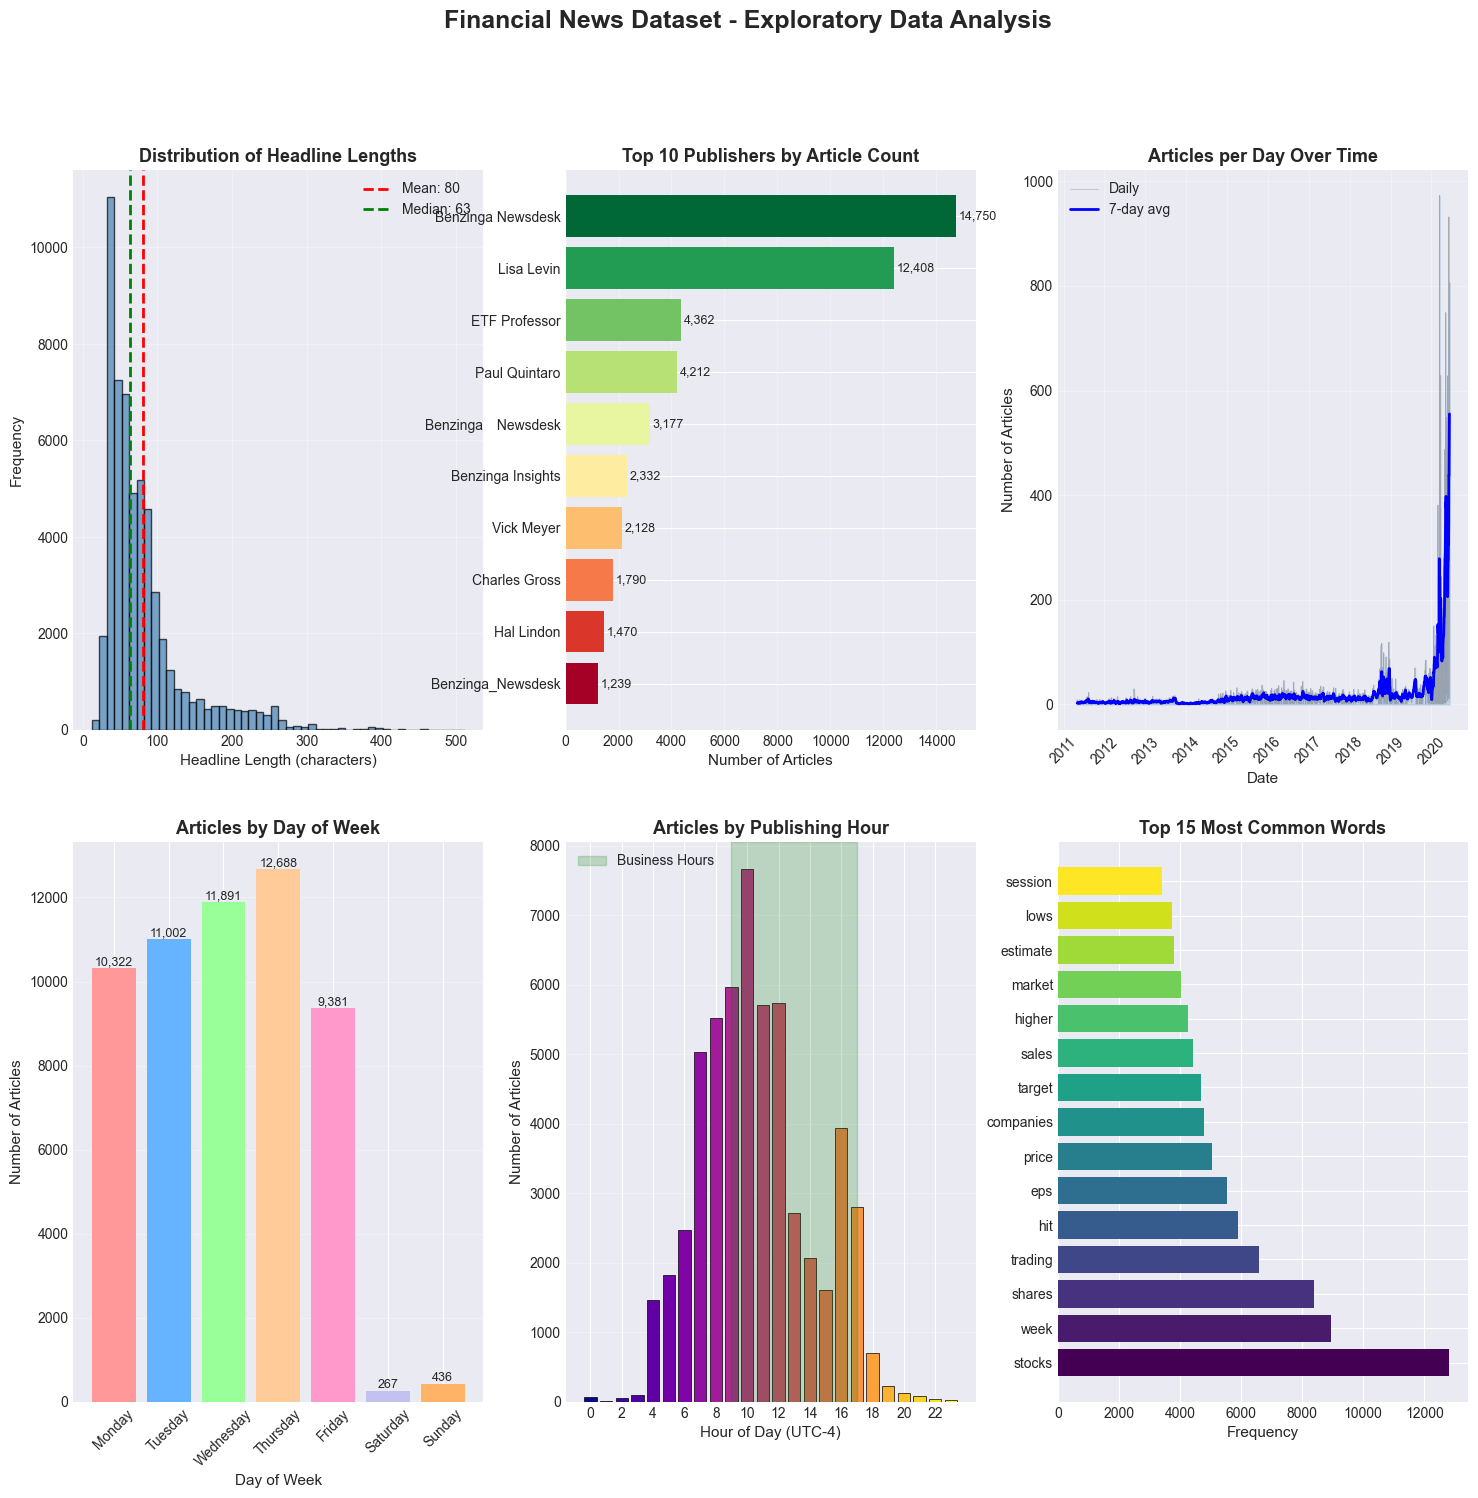

In [10]:
print("\n" + "="*70)
print("SECTION 9: CREATING VISUALIZATIONS")
print("="*70)

# Create figure with 2x3 grid (6 visualizations total)
fig = plt.figure(figsize=(18, 16))
fig.suptitle('Financial News Dataset - Exploratory Data Analysis', fontsize=18, fontweight='bold', y=0.98)

# Visualization 1: Headline Length Distribution
ax1 = fig.add_subplot(2, 3, 1)
if headline_col:
    ax1.hist(news_df['headline_length'], bins=50, edgecolor='black', color='steelblue', alpha=0.7)
    ax1.axvline(news_df['headline_length'].mean(), color='red', linestyle='--', linewidth=2, 
                label=f"Mean: {news_df['headline_length'].mean():.0f}")
    ax1.axvline(news_df['headline_length'].median(), color='green', linestyle='--', linewidth=2,
                label=f"Median: {news_df['headline_length'].median():.0f}")
    ax1.set_xlabel('Headline Length (characters)', fontsize=11)
    ax1.set_ylabel('Frequency', fontsize=11)
    ax1.set_title('Distribution of Headline Lengths', fontsize=13, fontweight='bold')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

# Visualization 2: Top Publishers
ax2 = fig.add_subplot(2, 3, 2)
if publisher_col:
    top_publishers = publisher_counts.head(10)
    colors = plt.cm.RdYlGn_r(np.linspace(0, 1, len(top_publishers)))
    bars = ax2.barh(range(len(top_publishers)), top_publishers.values, color=colors)
    ax2.set_yticks(range(len(top_publishers)))
    ax2.set_yticklabels([str(p)[:25] for p in top_publishers.index])
    ax2.set_xlabel('Number of Articles', fontsize=11)
    ax2.set_title('Top 10 Publishers by Article Count', fontsize=13, fontweight='bold')
    ax2.invert_yaxis()
    ax2.grid(True, alpha=0.3, axis='x')
    for i, (bar, val) in enumerate(zip(bars, top_publishers.values)):
        ax2.text(val + 100, bar.get_y() + bar.get_height()/2, f'{val:,}', va='center', fontsize=9)

# Visualization 3: Articles Over Time (7-day rolling average)
ax3 = fig.add_subplot(2, 3, 3)
if date_col:
    rolling_avg = daily_counts.rolling(window=7).mean()
    ax3.plot(daily_counts.index, daily_counts.values, linewidth=0.5, alpha=0.5, color='gray', label='Daily')
    ax3.plot(rolling_avg.index, rolling_avg.values, linewidth=2, color='blue', label='7-day avg')
    ax3.fill_between(daily_counts.index, daily_counts.values, alpha=0.2, color='steelblue')
    ax3.set_xlabel('Date', fontsize=11)
    ax3.set_ylabel('Number of Articles', fontsize=11)
    ax3.set_title('Articles per Day Over Time', fontsize=13, fontweight='bold')
    ax3.legend()
    ax3.tick_params(axis='x', rotation=45)
    ax3.grid(True, alpha=0.3)

# Visualization 4: Articles by Day of Week
ax4 = fig.add_subplot(2, 3, 4)
if date_col:
    colors_dow = ['#ff9999', '#66b3ff', '#99ff99', '#ffcc99', '#ff99cc', '#c2c2f0', '#ffb366']
    bars = ax4.bar(day_names, [day_counts.get(i, 0) for i in range(7)], color=colors_dow)
    ax4.set_xlabel('Day of Week', fontsize=11)
    ax4.set_ylabel('Number of Articles', fontsize=11)
    ax4.set_title('Articles by Day of Week', fontsize=13, fontweight='bold')
    ax4.tick_params(axis='x', rotation=45)
    ax4.grid(True, alpha=0.3, axis='y')
    for bar in bars:
        height = bar.get_height()
        ax4.text(bar.get_x() + bar.get_width()/2., height, f'{int(height):,}', ha='center', va='bottom', fontsize=9)

# Visualization 5: Articles by Hour
ax5 = fig.add_subplot(2, 3, 5)
if date_col:
    hours = hour_counts.index.tolist()
    counts = hour_counts.values
    colors_hours = plt.cm.plasma(np.linspace(0, 1, len(hours)))
    bars = ax5.bar(hours, counts, color=colors_hours, edgecolor='black', linewidth=0.5)
    ax5.set_xlabel('Hour of Day (UTC-4)', fontsize=11)
    ax5.set_ylabel('Number of Articles', fontsize=11)
    ax5.set_title('Articles by Publishing Hour', fontsize=13, fontweight='bold')
    ax5.set_xticks(range(0, 24, 2))
    ax5.grid(True, alpha=0.3, axis='y')
    ax5.axvspan(9, 17, alpha=0.2, color='green', label='Business Hours')
    ax5.legend(loc='upper left')

# Visualization 6: Top Words
ax6 = fig.add_subplot(2, 3, 6)
if headline_col:
    word_freq = pd.DataFrame({'word': words, 'count': word_counts})
    word_freq = word_freq.sort_values('count', ascending=False).head(15)
    colors_words = plt.cm.viridis(np.linspace(0, 1, len(word_freq)))
    bars = ax6.barh(range(len(word_freq)), word_freq['count'].values, color=colors_words)
    ax6.set_yticks(range(len(word_freq)))
    ax6.set_yticklabels(word_freq['word'].values)
    ax6.set_xlabel('Frequency', fontsize=11)
    ax6.set_title('Top 15 Most Common Words', fontsize=13, fontweight='bold')
    ax6.invert_yaxis